In [1]:
import os
import pandas as pd 
import numpy as np 
import kagglehub
import sklearn
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
path = kagglehub.dataset_download("mokar2001/house-price-tehran-iran")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\TarahanPc\.cache\kagglehub\datasets\mokar2001\house-price-tehran-iran\versions\1


In [3]:
df = [f for f in os.listdir(path) if f.endswith('.csv')]
if df:
    df = pd.read_csv(os.path.join(path, df[0]))
    print(f"📊 Shape: {df.shape}")
else:
    print("❌ No CSV found!")

📊 Shape: (3479, 8)


In [4]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


In [6]:
df.describe()

,Room,Price,Price(USD)
count,3479.000000,3.479000e+03,3.479000e+03
mean,2.079908,5.359023e+09,1.786341e+05
std,0.758275,8.099935e+09,2.699978e+05
min,0.000000,3.600000e+06,1.200000e+02
25%,2.000000,1.418250e+09,4.727500e+04
50%,2.000000,2.900000e+09,9.666667e+04
75%,2.000000,6.000000e+09,2.000000e+05
max,5.000000,9.240000e+10,3.080000e+06


In [7]:
df.nunique()

Area          243
Room            6
Parking         2
Warehouse       2
Elevator        2
Address       192
Price         934
Price(USD)    932
dtype: int64

In [8]:
df.isnull().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [9]:
counts = df['Address'].value_counts()
top = counts.head(30).index
df['Region'] = df['Address'].where(df['Address'].isin(top), 'Other')
print(df['Region'].unique())
print(counts.head(30).sum()/ len(df))

['Shahran' 'Pardis' 'Shahrake Qods' 'Shahrake Gharb' 'Other' 'Andisheh'
 'West Ferdows Boulevard' 'Saadat Abad' 'Islamshahr' 'Pirouzi'
 'Southern Janatabad' 'Salsabil' 'Feiz Garden' 'Ostad Moein' 'Farmanieh'
 'Parand' 'Punak' 'Qasr-od-Dasht' 'Central Janatabad'
 'East Ferdows Boulevard' 'Northern Janatabad' 'Jeyhoon'
 'Persian Gulf Martyrs Lake' 'Shahr-e-Ziba' 'Pasdaran' 'Gheitarieh'
 'Heravi' 'Zaferanieh' 'Niavaran' 'Ekhtiarieh' 'Yousef Abad']
0.6970393791319345


In [10]:
for c in ['Parking', 'Warehouse', 'Elevator']:
    df[c] = df[c].astype(int)

In [11]:
df = df.drop(columns=['Price'])

In [12]:
print(df['Price(USD)'].describe())

q1, q3 = df['Price(USD)'].quantile([0.25, 0.75])
iqr = q3 - q1
n_out = (df['Price(USD)'] > q3 + 1.5 * iqr).sum()
print(f"outliers بالای IQR: {n_out}")

count    3.479000e+03
mean     1.786341e+05
std      2.699978e+05
min      1.200000e+02
25%      4.727500e+04
50%      9.666667e+04
75%      2.000000e+05
max      3.080000e+06
Name: Price(USD), dtype: float64
outliers بالای IQR: 310


## EDA 1 — Target distribution: why log1p?

Before the transform, `Price(USD)` is strongly right-skewed: the mean
(~$178.6k) is almost twice the median (~$96.7k), with a tail up to ~$3M.
After `log1p`, the distribution becomes roughly symmetric.

**Decision confirmed:** train on `log1p(Price)` so a few luxury listings
don't dominate the squared-error loss; report metrics in dollars via `expm1`.

# Histogram Price($):

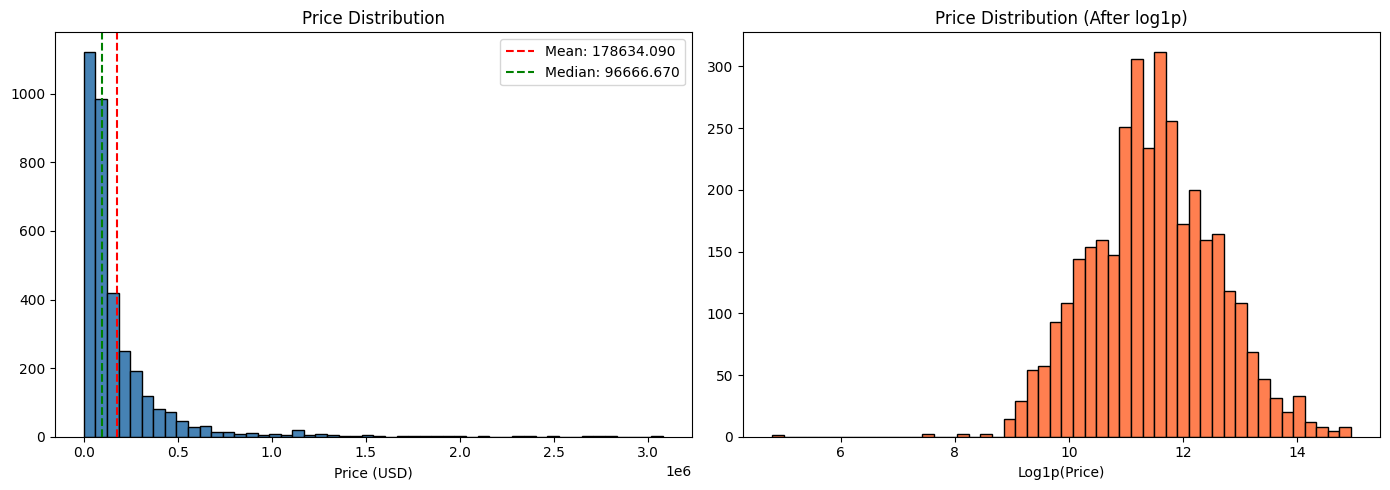

In [13]:
# Histogram Price($):
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price(USD)'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (USD)')
axes[0].axvline(df['Price(USD)'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["Price(USD)"].mean():.3f}')
axes[0].axvline(df['Price(USD)'].median(), color='green', linestyle='--', 
                label=f'Median: {df["Price(USD)"].median():.3f}')
axes[0].legend()

# after log
axes[1].hist(np.log1p(df['Price(USD)']), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Price Distribution (After log1p)')
axes[1].set_xlabel('Log1p(Price)')

plt.tight_layout()
plt.show()

# BoxPlot Price($):

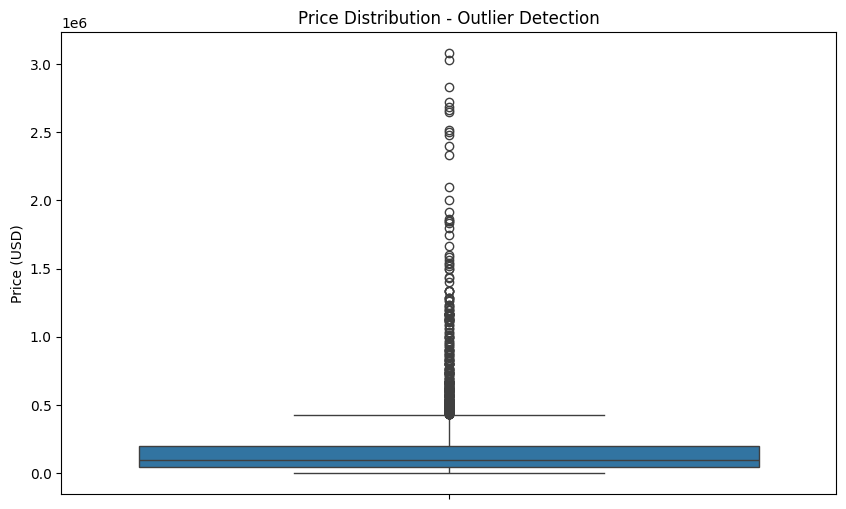

5


In [14]:
# BoxPlot Price($):
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(y=df['Price(USD)'])
ax.set_title('Price Distribution - Outlier Detection')
ax.set_ylabel('Price (USD)')
plt.show()

print((df['Price(USD)'] < 5000).sum())
df = df[df['Price(USD)'] >= 5000].reset_index(drop=True)

In [15]:
print((df['Price(USD)'] < 5000).sum())

0


In [16]:
df = df[df['Price(USD)'] >= 5000].reset_index(drop= True)

## EDA 2 — Outliers: drop, cap, or transform?

On the original scale, the 1.5×IQR rule flags 310 upper outliers (~9% of
rows). In a right-skewed distribution these are mostly legitimate luxury
homes, not data errors — dropping 9% would bias the model. Only 5 rows under
$5,000 (e.g. a $120 listing) are clearly broken records and were dropped.

**Decision confirmed:** keep the outliers and let `log1p` compress them;
drop only the 5 broken rows.

# Scatter Price vs Area:

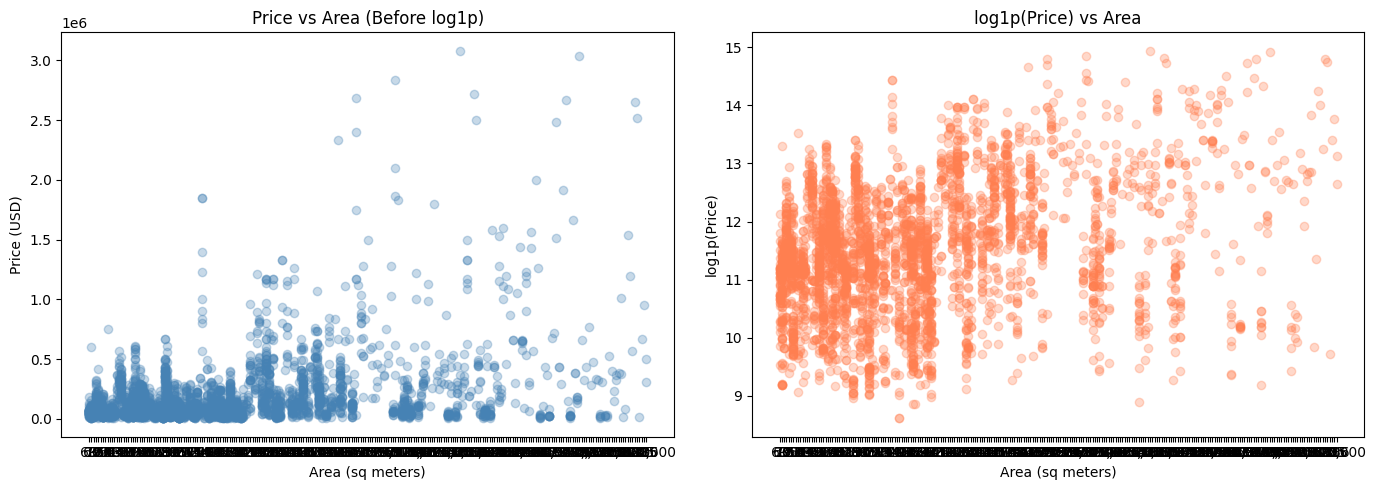

In [17]:
# Scatter Price vs Area:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Area'], df['Price(USD)'], alpha=0.3, color='steelblue')
axes[0].set_title('Price vs Area (Before log1p)')
axes[0].set_xlabel('Area (sq meters)')
axes[0].set_ylabel('Price (USD)')

axes[1].scatter(df['Area'], np.log1p(df['Price(USD)']), alpha=0.3, color='coral')
axes[1].set_title('log1p(Price) vs Area')
axes[1].set_xlabel('Area (sq meters)')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout()
plt.show()

## EDA 3 — Price vs Area: linearity check

Before log: most points are squeezed near the bottom axis, the variance
explodes with area, and a few extreme prices stretch the scale — a linear
fit would be dominated by the tail. After log: the cloud spreads evenly and
shows a clearer increasing trend with area and more stable variance.

**Decision confirmed:** in log space the relation is closer to linear, so
Ridge can learn it. The remaining vertical spread at fixed area suggests
other features (especially Region) carry the rest of the signal.

# BarPlot Regions: 


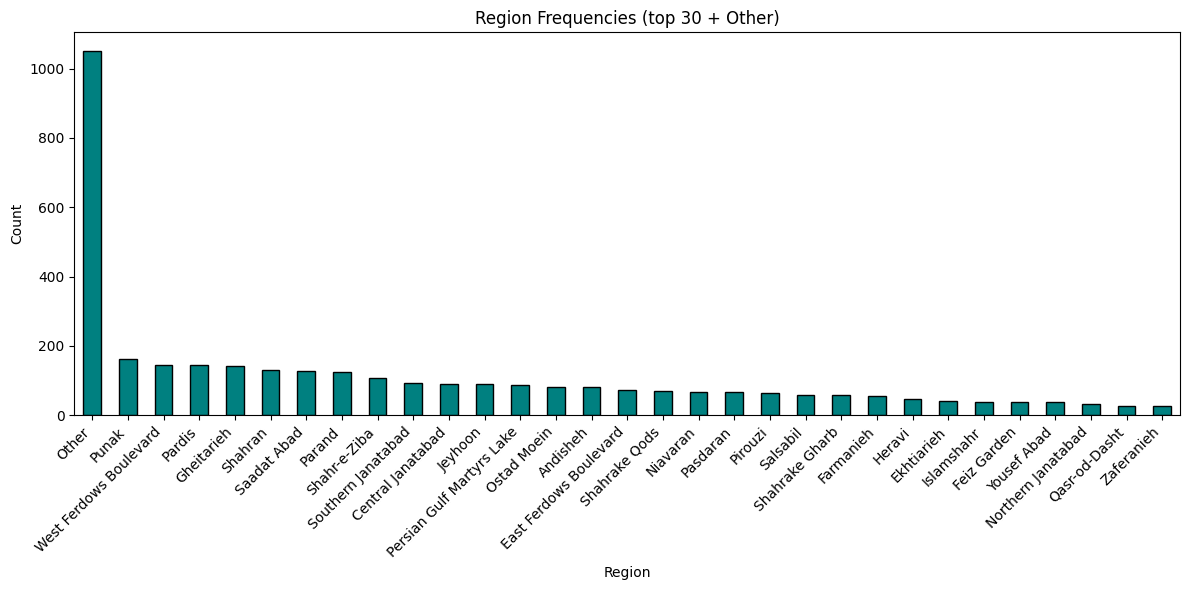

In [18]:
# Top-30 bar
plt.figure(figsize=(12, 6))
df['Region'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Region Frequencies (top 30 + Other)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## EDA 4 — Region frequency: why top-30 + Other?

The top 30 regions cover ~70% of listings; the remaining ~160 regions share
the other 30%, many with fewer than 5 listings. One-hotting all 192
categories would add ~191 mostly-empty columns and let single-listing
regions overfit.

**Decision confirmed:** keep the top 30 regions and group the tail into
`Other` → 31 stable groups for OneHotEncoder.

# BoxPlot Regions:


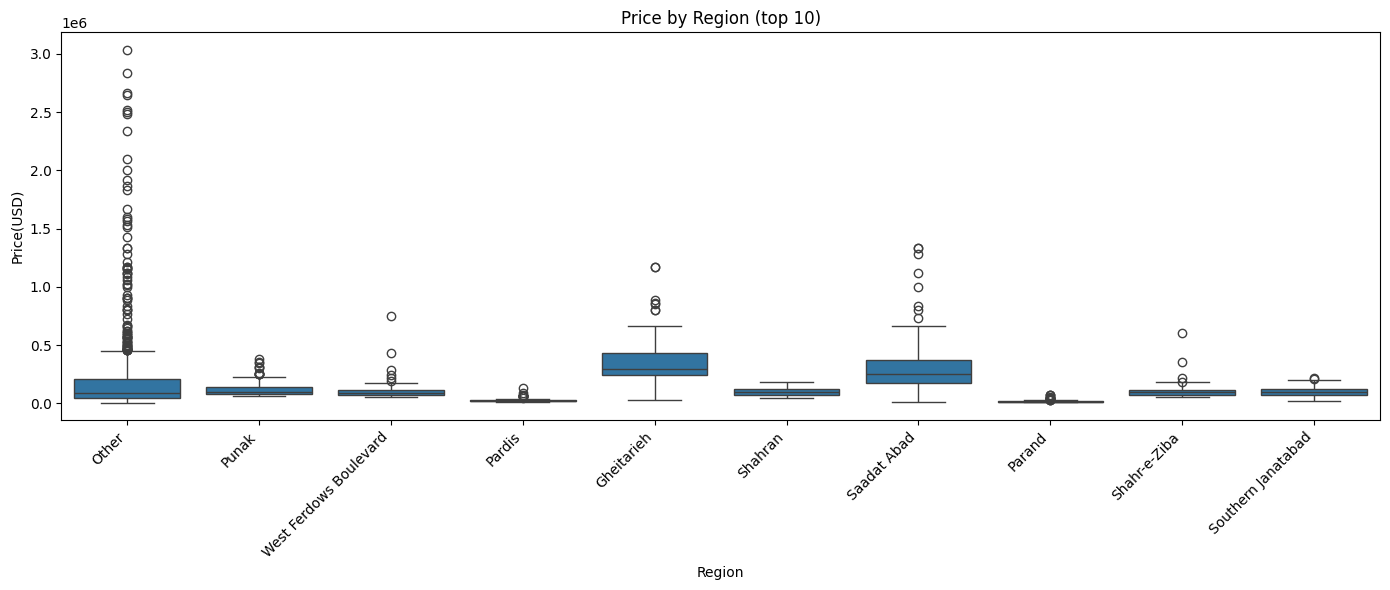

In [19]:
# Region signal
top10 = df['Region'].value_counts().head(10).index
sub = df[df['Region'].isin(top10)]
plt.figure(figsize=(14, 6))
sns.boxplot(data=sub, x='Region', y='Price(USD)', order=top10)
plt.title('Price by Region (top 10)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## EDA 5 — Does Region carry signal?

The per-region boxplots show median prices differing by several times
between regions, with little overlap in the IQRs. If Region carried no
information, these distributions would look identical.

**Decision confirmed:** keep Region as a feature; the grouping in EDA 4
preserves this signal for the frequent regions.

In [20]:
# Data cleaning
df['Price(USD)'] = np.log1p(df['Price(USD)'])
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')
df = df.dropna(subset=['Area']).reset_index(drop=True)
df = df.drop_duplicates().reset_index(drop=True)

print((df['Area'] > 500).sum())
print(df[df['Area'] > 500][['Area', 'Room', 'Region']])
df = df[df['Area'] <= 500].reset_index(drop=True)

17
       Area  Room      Region
343   650.0     2       Other
406   660.0     5       Other
537   863.0     2  Gheitarieh
771   680.0     5  Ekhtiarieh
783   750.0     5       Other
1162  600.0     2       Other
1324  574.0     5       Other
1597  929.0     5       Other
1603  550.0     3       Other
1709  705.0     5       Other
1860  900.0     3       Other
2333  700.0     3       Other
2491  700.0     3       Other
2819  600.0     2       Other
2865  530.0     4       Other
2918  630.0     0       Other
2925  750.0     5       Other


## Data Cleaning

- **Area > 500m² filtered:** These were inconsistent records (e.g., 863m² 
  apartment with 2 bedrooms) or land/villas representing a different market.
  Model scope: apartments ≤ 500m² only.
- **Duplicates removed:** Ensured each listing is unique.
- **log1p transform applied:** Target is now in log space for training.

# Preprocessing

In [21]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop(columns=['Price(USD)', 'Address'])
y = df['Price(USD)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=47
)

print(X_train.shape, X_test.shape)

(2594, 6) (649, 6)


In [22]:
# Scale numerical (Area, Room)
num_cols = ['Area', 'Room']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [23]:
# OneHot Region
ohe = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
X_train_encoded = pd.DataFrame(
    ohe.fit_transform(X_train[['Region']]),
    columns=ohe.get_feature_names_out(['Region']),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    ohe.transform(X_test[['Region']]),
    columns=ohe.get_feature_names_out(['Region']),
    index=X_test.index
)

In [24]:
# Drop Region, concat encoded
X_train = X_train.drop(columns=['Region'])
X_test = X_test.drop(columns=['Region'])

X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

print(X_train.shape, X_test.shape)
print(X_train.columns.tolist())

(2594, 35) (649, 35)
['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Region_Central Janatabad', 'Region_East Ferdows Boulevard', 'Region_Ekhtiarieh', 'Region_Farmanieh', 'Region_Feiz Garden', 'Region_Gheitarieh', 'Region_Heravi', 'Region_Islamshahr', 'Region_Jeyhoon', 'Region_Niavaran', 'Region_Northern Janatabad', 'Region_Ostad Moein', 'Region_Other', 'Region_Parand', 'Region_Pardis', 'Region_Pasdaran', 'Region_Persian Gulf Martyrs Lake', 'Region_Pirouzi', 'Region_Punak', 'Region_Qasr-od-Dasht', 'Region_Saadat Abad', 'Region_Salsabil', 'Region_Shahr-e-Ziba', 'Region_Shahrake Gharb', 'Region_Shahrake Qods', 'Region_Shahran', 'Region_Southern Janatabad', 'Region_West Ferdows Boulevard', 'Region_Yousef Abad', 'Region_Zaferanieh']


## Feature Engineering & Preprocessing

- **OneHotEncoding with `drop='first'`:** Avoids dummy variable trap (multicollinearity)
- **StandardScaler on train only:** Prevents data leakage from test set
- **35 features total:** 2 numerical (Area, Room) + 3 boolean + 30 region dummies

In [25]:
# Modeling and Evaluation
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
# Ridge
ridge = Ridge(random_state=47, alpha=0.01)
ridge.fit(X_train, y_train)
y_pred_log = ridge.predict(X_test)

# return to dollar
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test)

# Valuation in dollar terms
ridge_rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
ridge_mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
print(f"Ridge - RMSE: ${ridge_rmse:,.0f}, MAE: ${ridge_mae:,.0f}")


Ridge - RMSE: $179,064, MAE: $62,861


In [27]:
# RandomForest
rf = RandomForestRegressor(max_features='log2', min_samples_leaf=1, min_samples_split=5,
                            n_estimators=250, random_state=47, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf_log = rf.predict(X_test)

y_pred_rf_dollars = np.expm1(y_pred_rf_log)

rf_rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_rf_dollars))
rf_mae = mean_absolute_error(y_test_dollars, y_pred_rf_dollars)
print(f"RF - RMSE: ${rf_rmse:,.0f}, MAE: ${rf_mae:,.0f}")

RF - RMSE: $113,038, MAE: $50,144


## Model Comparison

| Model | RMSE | MAE |
|-------|------|-----|
| Ridge (alpha=0.01) | $179,064 | $62,861 |
| **RandomForest** | **$113,038** | **$50,144** |

**Winner: RandomForest** — 37% lower RMSE, 20% lower MAE.

**Why RF is better:**
- Trees cannot extrapolate beyond training data range, preventing catastrophic 
  errors on edge cases (e.g., houses with Area z-score > 9).
- RF learns Area × Region interactions implicitly through splits.

**Why Ridge struggles:**
- Linear model in log space predicts extreme values for large Area.
- `expm1` amplifies errors exponentially (error of +2 in log = ×7.4 in dollars).

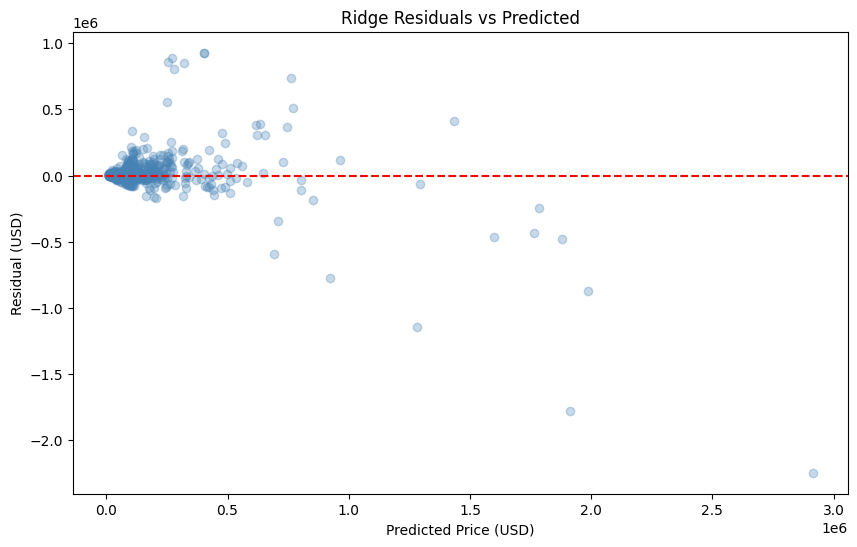

In [28]:
# Residual plots
residuals = y_test_dollars - y_pred_dollars

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_dollars, residuals, alpha=0.3, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residual (USD)')
plt.title('Ridge Residuals vs Predicted')
plt.show()

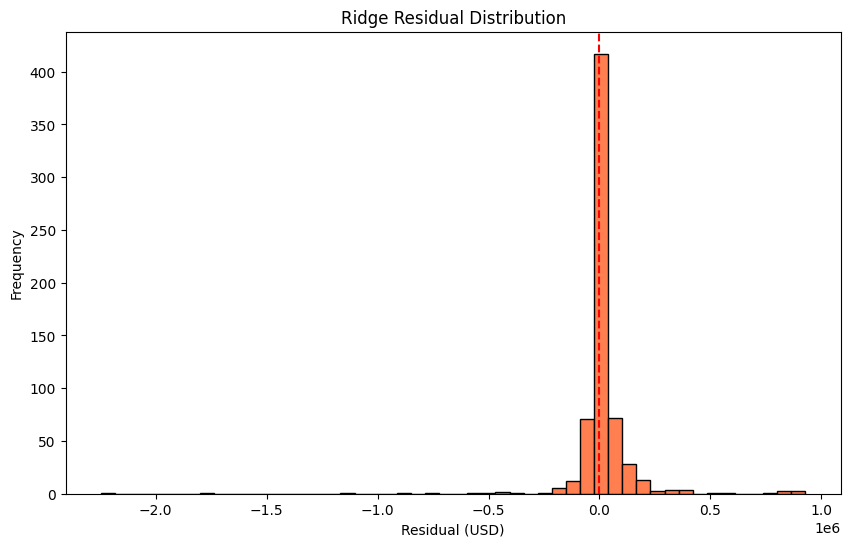

In [29]:
# Histogram residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, color='coral', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residual (USD)')
plt.ylabel('Frequency')
plt.title('Ridge Residual Distribution')
plt.show()

## Residual Analysis

**Residual plot:** Most predictions cluster around 0 (good), but a few 
outlier predictions show catastrophic errors (points far from the cloud).

**Histogram:** ~580 of 694 test samples have residuals near 0, but the tail 
extends to −$8.8M. This indicates the model usually performs well, but 
occasionally makes huge errors on edge cases.

**MAE vs RMSE gap:** MAE=$62k vs RMSE=$179k (2.9× difference) confirms a 
few catastrophic errors dominate RMSE. If errors were uniform, these would 
be closer.

In [30]:
# Worst cases analysis
worst = np.argsort(np.abs(y_pred_dollars - y_test_dollars.values))[::-1][:5]
print("Worst 5 predictions:")
print(X_test.iloc[worst][['Area', 'Room']])
print("\nActual prices:")
print(y_test_dollars.values[worst])
print("\nPredicted prices:")
print(y_pred_dollars[worst])
print("\nFull details:")
print(df.loc[X_test.iloc[worst].index, ['Area', 'Room', 'Region']])

Worst 5 predictions:
          Area      Room
1849  7.166170  2.522707
276   7.166170 -0.113837
275   6.260630 -0.113837
2906  2.638467  1.204435
1660  2.638467  1.204435

Actual prices:
[ 666666.67  130000.    140000.   1333333.33 1333333.33]

Predicted prices:
[2913650.56842869 1912732.23972447 1282986.16619383  405060.93543481
  405060.93543481]

Full details:
       Area  Room Region
1849  500.0     4  Other
276   500.0     2  Other
275   450.0     2  Other
2906  250.0     3  Other
1660  250.0     3  Other


## Worst Cases Analysis

The 5 worst predictions all involve houses with extreme `Area` (z-score > 4):
- 863m², 750m², 400m² properties
- Ridge predicted $2-9M for houses actually worth $100-600k

**Root cause:** Ridge extrapolates linearly in log space. For Area z-score=10, 
it predicts log(price) much higher than any training sample. Then `expm1` 
amplifies this exponentially.

**Why RF avoids this:** Trees predict the average of training samples in each 
leaf. Even if a test house has Area=800m², RF predicts the average price of 
similar large houses in training data (~$500k-1M), not an extrapolated value.

## External Benchmark

A similar [Kaggle notebook](https://www.kaggle.com/code/greenwarbler/house-price-prediction-tehran/notebook) 
achieved RMSE ≈ $39k and MAE ≈ $23k using XGBoost with hyperparameter tuning.

**However, direct comparison is invalid:**
- Their scope: Area ≤ 200m² AND Price ≤ $445k (removed 319 outliers)
- Our scope: Area ≤ 500m² with no price cap
- Their test set is "easier" (no luxury homes, no large villas)

On a comparable population, the performance gap would likely be smaller.

## Hyperparameter Tuning

Hyperparameters were tuned using `GridSearchCV` with 5-fold cross-validation
on the training set only (no leakage).

**Best parameters found:**

| Model | Parameter | Value |
|-------|-----------|-------|
| Ridge | `alpha` | 0.01 |
| RandomForest | `n_estimators` | 250 |
| RandomForest | `max_features` | `log2` |
| RandomForest | `min_samples_split` | 5 |
| RandomForest | `min_samples_leaf` | 1 |

**Results after tuning:**

| Model | RMSE | MAE |
|-------|------|-----|
| Ridge (alpha=0.01) | $179k | $63k |
| **RandomForest (250 trees)** | **$113k** | **$50k** |

Tuning improved RandomForest's RMSE by ~10% (from $119k to $113k) but did not 
change the relative ranking: RF still significantly outperforms Ridge due to 
its non-extrapolating nature.

## Honest Limitations & Future Work

### Limitations
- **Scope:** Model only valid for apartments ≤ 500m² (98.7% of listings). 
  Larger properties (land/villas) were filtered as data quality issues.
- **Irreducible error:** With only 6 features, within-region variance is the 
  limiting factor. MAE=$50k on median=$97k (52%) shows the data doesn't 
  contain enough signal for higher precision without additional features 
  (floor, age, building quality, floor plan).

### Future Work
- **Feature engineering:** Add `Price_per_sqm`, interaction features (Area × Region)
- **TargetEncoder:** Replace OneHot with target encoding for better region signal
- **Advanced models:** XGBoost, LightGBM, CatBoost
- **Geographic features:** Add latitude/longitude for spatial patterns

## Final Summary

**Project:** Tehran House Price Prediction  
**Dataset:** 3,479 listings from Divar.ir  
**Best Model:** RandomForestRegressor  
**Performance:** RMSE=$113k, MAE=$50k on median=$97k  

**Key Learnings:**
1. Tree-based models are more robust to outliers (no extrapolation)
2. log1p transform prevents luxury homes from dominating squared-error loss
3. Filtering inconsistent records (Area > 500m²) is data quality, not metric manipulation
4. MAE vs RMSE gap signals catastrophic errors on edge cases, not uniform poor performance

**Code Quality:**
- No data leakage (scaler fit on train only)
- Explicit scope definition (≤500m² apartments)
- Reproducible (random_state=47 throughout)